In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv(r"D:\ML\Scikit-Learn-Tutorial-\New ML\placement (1).csv")

In [3]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


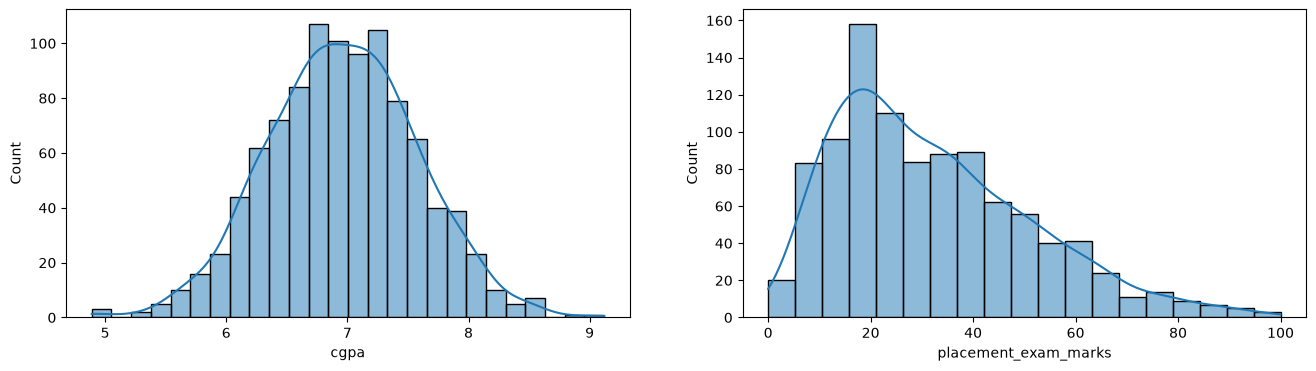

In [9]:
plt.figure(figsize=(16,4))

plt.subplot(1,2,1)
sns.histplot(df['cgpa'], kde=True)

plt.subplot(1,2,2)
sns.histplot(df['placement_exam_marks'],kde=True)

plt.show()

In [10]:
print('mean value of cgpa', df['cgpa'].mean())
print("standard values of  cgpa", df['cgpa'].std())
print('min value of cgpa', df['cgpa'].min())
print('max value of cgpa ', df['cgpa'].max())

mean value of cgpa 6.96124
standard values of  cgpa 0.6158978751323896
min value of cgpa 4.89
max value of cgpa  9.12


In [12]:
# finding the boundary
print('Highest value of cgpa', df['cgpa'].mean()+3*df['cgpa'].std())
print('Lowest value of cgpa' , df['cgpa'].mean()-3*df['cgpa'].std())

Highest value of cgpa 8.808933625397168
Lowest value of cgpa 5.113546374602832


In [13]:
# finding outlier 
df.shape

(1000, 3)

In [15]:
df[(df['cgpa']>8.80) | (df['cgpa']<5.11)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


In [ ]:
# approach 1 trimming and remove the outlier 
new_df = df[(df['cgpa']>5.11) & (df['cgpa']<8.80)]
new_df
new_df.shape

(995, 3)

In [21]:
# Approach 2 Capping the values
df['z_score'] = (df['cgpa'] - df['cgpa'].mean())/df['cgpa'].std()
df.head()

,cgpa,placement_exam_marks,placed,z_score
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


In [23]:
df[df['z_score']>3]

,cgpa,placement_exam_marks,placed,z_score
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062


In [28]:
df[df['z_score']<-3]

,cgpa,placement_exam_marks,placed,z_score
485,4.92,44.0,1,-3.314251
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [29]:
df[(df['z_score']< -3) | (df['z_score']>3)]

,cgpa,placement_exam_marks,placed,z_score
485,4.92,44.0,1,-3.314251
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [32]:
new_df = df[(df['z_score']>-3) & (df['z_score']<3)]
new_df
new_df.shape

(995, 4)

In [ ]:
# capping 
upper_limit = df['cgpa'].mean()+ 3*df['cgpa'].std()
lower_limit = df['cgpa'].mean() - 3*df['cgpa'].std()


In [35]:
print(upper_limit)
print(lower_limit)

8.808933625397168
5.113546374602832


In [36]:
df['cgpa'] = np.where(
    df['cgpa']>upper_limit,
    upper_limit,
    np.where(
        df['cgpa']<lower_limit,
        lower_limit,
        df['cgpa']
    )
)

In [37]:
df.shape

(1000, 4)